<a href="https://colab.research.google.com/github/ruck-syu/cvlab/blob/main/CV_Lab1_part2_1RUA24CSE0535.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt


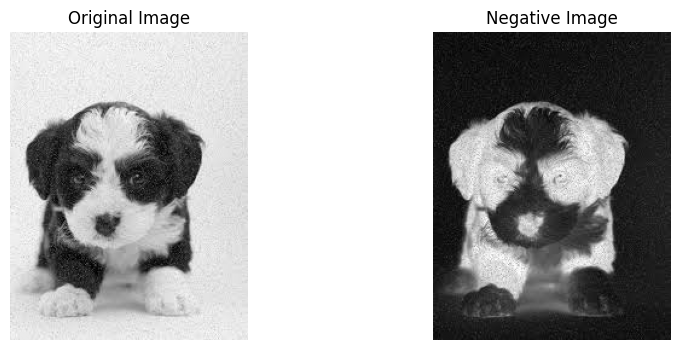

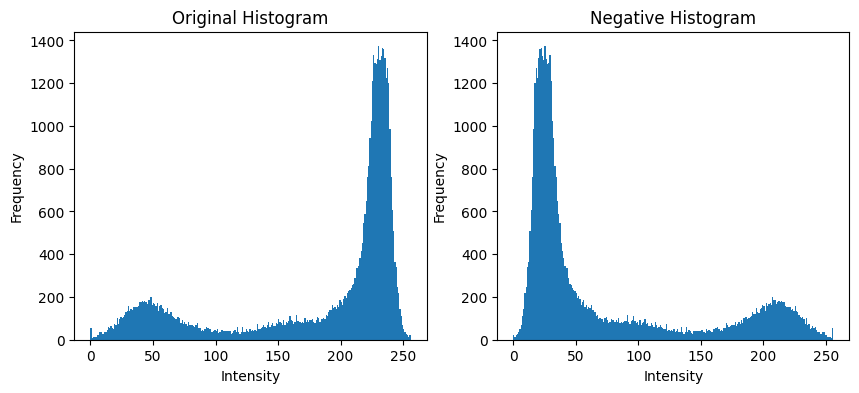

In [3]:
# Task 1

img = cv2.imread("dog.jpg", cv2.IMREAD_GRAYSCALE)

negative = 255 - img

plt.figure(figsize=(10, 4))

plt.subplot(1, 2, 1)
plt.imshow(img, cmap="gray")
plt.title("Original Image")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(negative, cmap="gray")
plt.title("Negative Image")
plt.axis("off")

plt.show()

plt.figure(figsize=(10, 4))

plt.subplot(1, 2, 1)
plt.hist(img.ravel(), bins=256, range=[0, 256])
plt.title("Original Histogram")
plt.xlabel("Intensity")
plt.ylabel("Frequency")

plt.subplot(1, 2, 2)
plt.hist(negative.ravel(), bins=256, range=[0, 256])
plt.title("Negative Histogram")
plt.xlabel("Intensity")
plt.ylabel("Frequency")

plt.show()

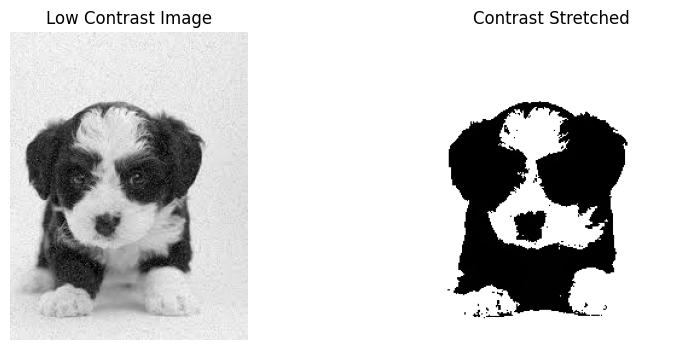

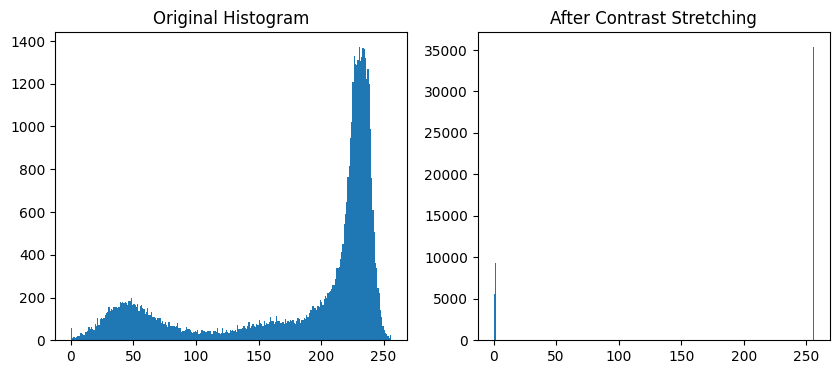

In [ ]:
# Task 2

img = cv2.imread("dog.jpg", cv2.IMREAD_GRAYSCALE)

r1 = 50
r2 = 180

stretched = np.zeros_like(img, dtype=np.uint8)

stretched[img < r1] = 0

mask = (img >= r1) & (img <= r2)

stretched[mask] = (
    255 * (img[mask] - r1) / (r2 - r1)
).astype(np.uint8)

stretched[img > r2] = 255

plt.figure(figsize=(10, 4))

plt.subplot(1, 2, 1)
plt.imshow(img, cmap="gray")
plt.title("Low Contrast Image")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(stretched, cmap="gray")
plt.title("Contrast Stretched")
plt.axis("off")

plt.show()

plt.figure(figsize=(10, 4))

plt.subplot(1, 2, 1)
plt.hist(img.ravel(), bins=256, range=(0, 256))
plt.title("Original Histogram")

plt.subplot(1, 2, 2)
plt.hist(stretched.ravel(), bins=256, range=(0, 256))
plt.title("After Contrast Stretching")

plt.show()

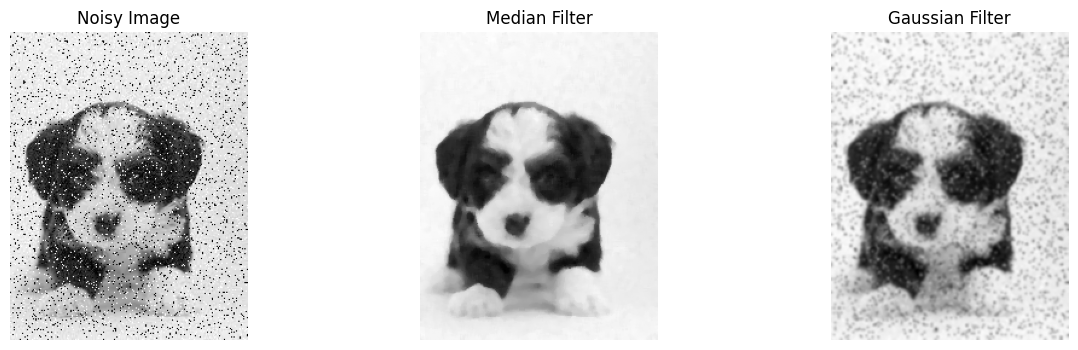

In [ ]:
# Task 3

img = cv2.imread("dog.jpg", cv2.IMREAD_GRAYSCALE)

noisy = img.copy()

amount = 0.05
num_pixels = int(amount * img.size)

# Add salt noise
coords = (
    np.random.randint(0, img.shape[0], num_pixels),
    np.random.randint(0, img.shape[1], num_pixels)
)
noisy[coords] = 255

# Add pepper noise
coords = (
    np.random.randint(0, img.shape[0], num_pixels),
    np.random.randint(0, img.shape[1], num_pixels)
)
noisy[coords] = 0

median = cv2.medianBlur(noisy, 5)

gaussian = cv2.GaussianBlur(noisy, (5, 5), 0)

plt.figure(figsize=(15, 4))

plt.subplot(1, 3, 1)
plt.imshow(noisy, cmap="gray")
plt.title("Noisy Image")
plt.axis("off")

plt.subplot(1, 3, 2)
plt.imshow(median, cmap="gray")
plt.title("Median Filter")
plt.axis("off")

plt.subplot(1, 3, 3)
plt.imshow(gaussian, cmap="gray")
plt.title("Gaussian Filter")
plt.axis("off")

plt.show()

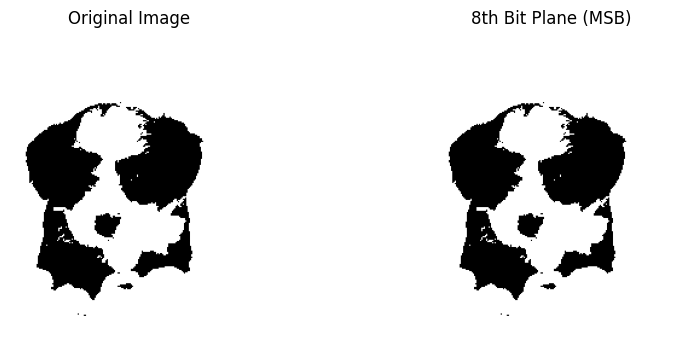

In [ ]:
# Task 4

img = cv2.imread("dog.jpg", cv2.IMREAD_GRAYSCALE)
bit_plane_8 = (img >> 7) & 1
bit_plane_8 = bit_plane_8 * 255
plt.figure(figsize=(10, 4))
plt.subplot(1,2,1)
plt.imshow(bit_plane_8, cmap="gray")
plt.title("Original Image")
plt.axis("off")
plt.subplot(1, 2, 2)
plt.imshow(bit_plane_8, cmap="gray")
plt.title("8th Bit Plane (MSB)")
plt.axis("off")

plt.show()

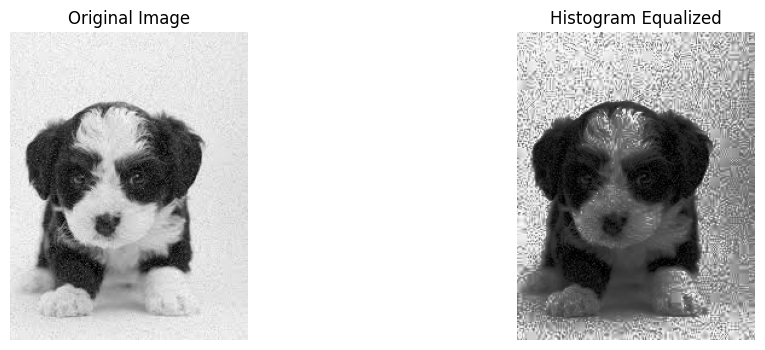

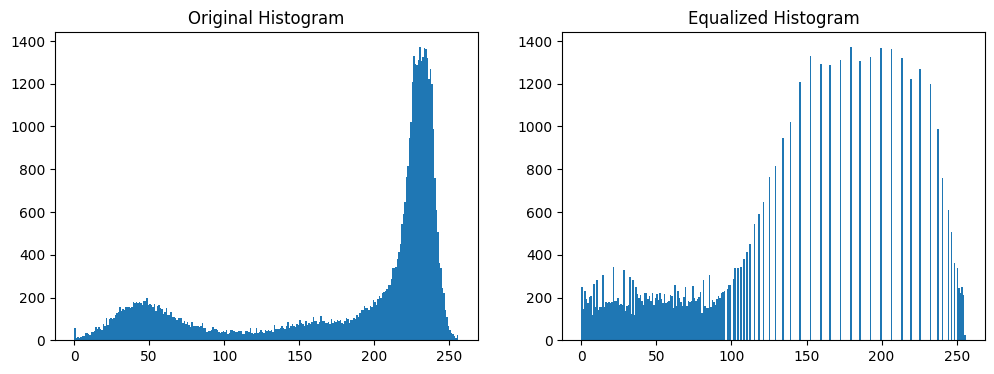

In [ ]:
# Task 5

img = cv2.imread("dog.jpg", cv2.IMREAD_GRAYSCALE)
hist = np.zeros(256, dtype=int)
for pixel in img.ravel():
    hist[pixel] += 1
cdf = np.cumsum(hist)
cdf_min = cdf[cdf>0][0]
cdf_normalized = ((cdf - cdf_min) /(img.size - cdf_min)) * 255
cdf_normalized = np.clip(cdf_normalized, 0 , 255)
mapping = cdf_normalized.astype(np.uint8)
equalized = mapping[img]
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.imshow(img, cmap="gray")
plt.title("Original Image")
plt.axis("off")
plt.subplot(1, 2, 2)
plt.imshow(equalized, cmap="gray")
plt.title("Histogram Equalized")
plt.axis("off")
plt.show()
plt.figure(figsize = (12,4))
plt.subplot(1,2,1)
plt.hist(img.ravel(), bins=256, range=(0,256))
plt.title("Original Histogram")

plt.subplot(1,2,2)
plt.hist(equalized.ravel(), bins=256, range=(0,256))
plt.title("Equalized Histogram")
plt.show()

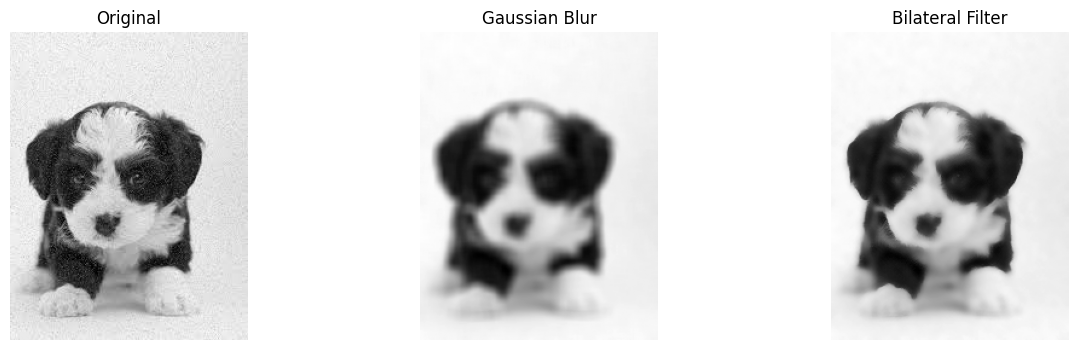

In [ ]:
# Task 6

img = cv2.imread("dog.jpg", cv2.IMREAD_GRAYSCALE)

gaussian = cv2.GaussianBlur(img,(9, 9),75)

bilateral = cv2.bilateralFilter(img,9,75,75)
plt.figure(figsize=(15, 4))
plt.subplot(1, 3, 1)
plt.imshow(img, cmap="gray")
plt.title("Original")
plt.axis("off")
plt.subplot(1, 3, 2)
plt.imshow(gaussian, cmap="gray")
plt.title("Gaussian Blur")
plt.axis("off")
plt.subplot(1, 3, 3)
plt.imshow(bilateral, cmap="gray")
plt.title("Bilateral Filter")
plt.axis("off")

plt.show()

### Additional Practice Problems

In [ ]:
# Question 1

values = [20, 50, 100, 150, 200]

for i in values:
    negative = 255 - i
    print(f"Input: {i} -> Output: {negative}")


Input: 20 -> Output: 235
Input: 50 -> Output: 205
Input: 100 -> Output: 155
Input: 150 -> Output: 105
Input: 200 -> Output: 55


In [ ]:
# Question 2

r1 = 60
r2 = 180
input_values = [60, 90, 120, 150, 180]

for val in input_values:

    if val <= r1:
        output = 0
    elif val >= r2:
        output = 255
    else:
        output = 255 * (val - r1) / (r2 - r1)

    print(f"Input: {val} -> Output: {output:.2f}")

Input: 60 -> Output: 0.00
Input: 90 -> Output: 63.75
Input: 120 -> Output: 127.50
Input: 150 -> Output: 191.25
Input: 180 -> Output: 255.00


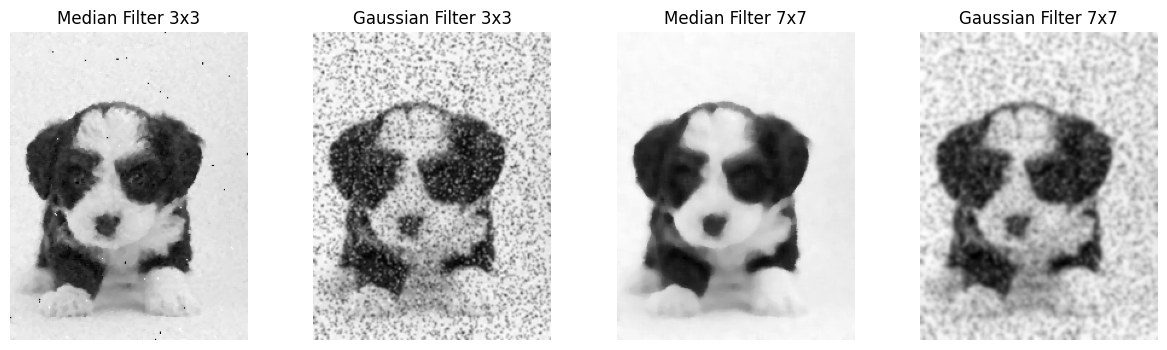

In [ ]:
# Question 3

img = cv2.imread("dog.jpg", cv2.IMREAD_GRAYSCALE)

noisy = img.copy()

amount = 0.1
num_pixels = int(amount * img.size)

# Add salt noise
coords = (
    np.random.randint(0, img.shape[0], num_pixels),
    np.random.randint(0, img.shape[1], num_pixels)
)
noisy[coords] = 255

# Add pepper noise
coords = (
    np.random.randint(0, img.shape[0], num_pixels),
    np.random.randint(0, img.shape[1], num_pixels)
)
noisy[coords] = 0

median = cv2.medianBlur(noisy, 3)

gaussian = cv2.GaussianBlur(noisy, (3, 3), 0)

median7 = cv2.medianBlur(noisy, 7)

gaussian7 = cv2.GaussianBlur(noisy, (7, 7), 0)

plt.figure(figsize=(15, 4))



plt.subplot(1, 4, 1)
plt.imshow(median, cmap="gray")
plt.title("Median Filter 3x3")
plt.axis("off")

plt.subplot(1, 4, 2)
plt.imshow(gaussian, cmap="gray")
plt.title("Gaussian Filter 3x3")
plt.axis("off")

plt.subplot(1, 4, 3)
plt.imshow(median7, cmap="gray")
plt.title("Median Filter 7x7")
plt.axis("off")

plt.subplot(1, 4, 4)
plt.imshow(gaussian7, cmap="gray")
plt.title("Gaussian Filter 7x7")
plt.axis("off")

plt.show()

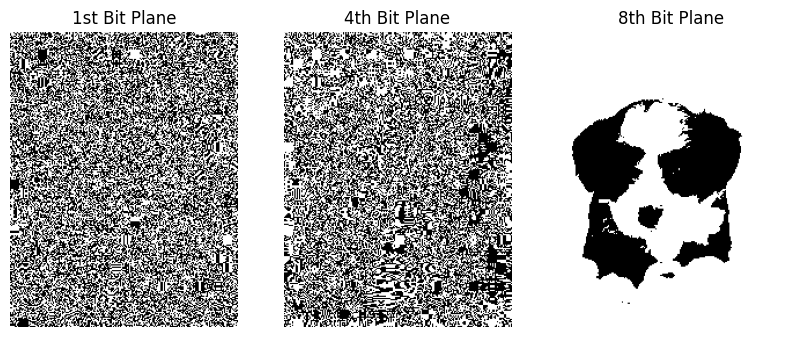

In [ ]:
# Question 4

img = cv2.imread("dog.jpg", cv2.IMREAD_GRAYSCALE)
bit_plane_1 = (img >> 0) & 1
bit_plane_1 = bit_plane_1 * 255

bit_plane_4 = (img >> 3) & 1
bit_plane_4 = bit_plane_4 * 255

bit_plane_8 = (img >> 7) & 1
bit_plane_8 = bit_plane_8 * 255

plt.figure(figsize=(10, 4))
plt.subplot(1,3,1)
plt.imshow(bit_plane_1, cmap="gray")
plt.title("1st Bit Plane")
plt.axis("off")

plt.subplot(1, 3, 2)
plt.imshow(bit_plane_4, cmap="gray")
plt.title("4th Bit Plane")
plt.axis("off")

plt.subplot(1, 3, 3)
plt.imshow(bit_plane_8, cmap="gray")
plt.title("8th Bit Plane")
plt.axis("off")

plt.show()

In [ ]:
# Question 5

intensities = [0, 1, 2, 3]
hist_counts = [2, 3, 4, 1]

cdf = []
current_sum = 0
for count in hist_counts:
    current_sum += count
    cdf.append(current_sum)

print("Intensity | Count | CDF")
print("----------|-------|----")
for i in range(len(intensities)):
    print(f"    {intensities[i]}     |   {hist_counts[i]}   |  {cdf[i]}")

Intensity | Count | CDF
----------|-------|----
    0     |   2   |  2
    1     |   3   |  5
    2     |   4   |  9
    3     |   1   |  10


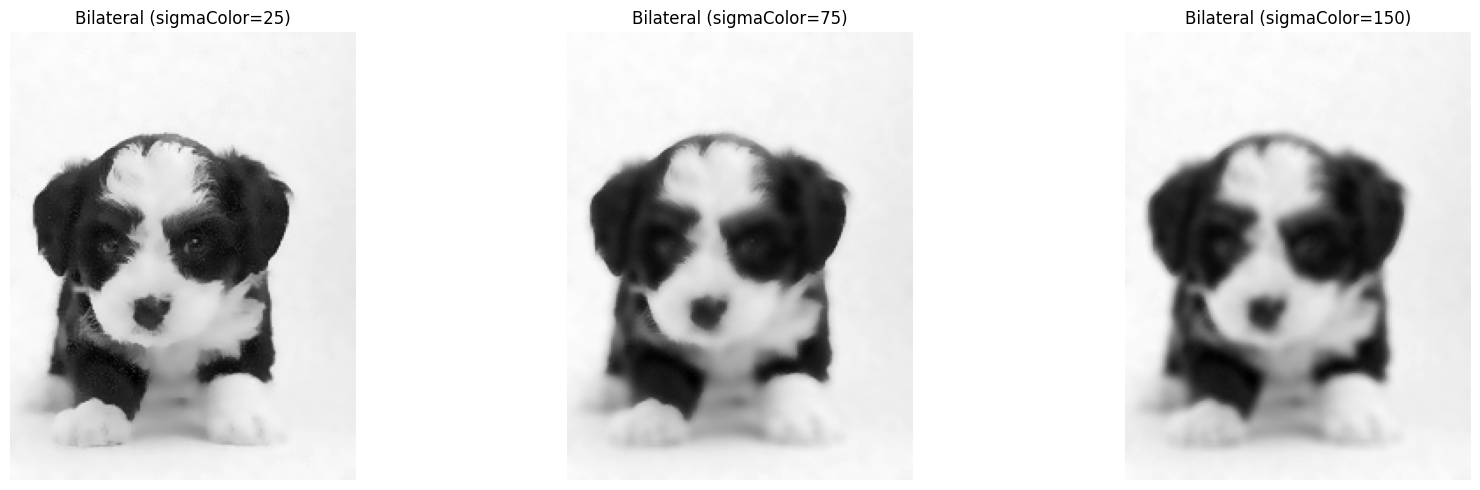

In [ ]:
# Question 6

mg = cv2.imread('dog.jpg', cv2.IMREAD_GRAYSCALE)

sigma_colors = [25, 75, 150]
results = []

for sc in sigma_colors:
    res = cv2.bilateralFilter(img, 9, sc, 75)
    results.append(res)

plt.figure(figsize=(18, 5))

for i, sc in enumerate(sigma_colors):
    plt.subplot(1, 3, i + 1)
    plt.imshow(results[i], cmap='gray')
    plt.title(f'Bilateral (sigmaColor={sc})')
    plt.axis('off')

plt.tight_layout()
plt.show()

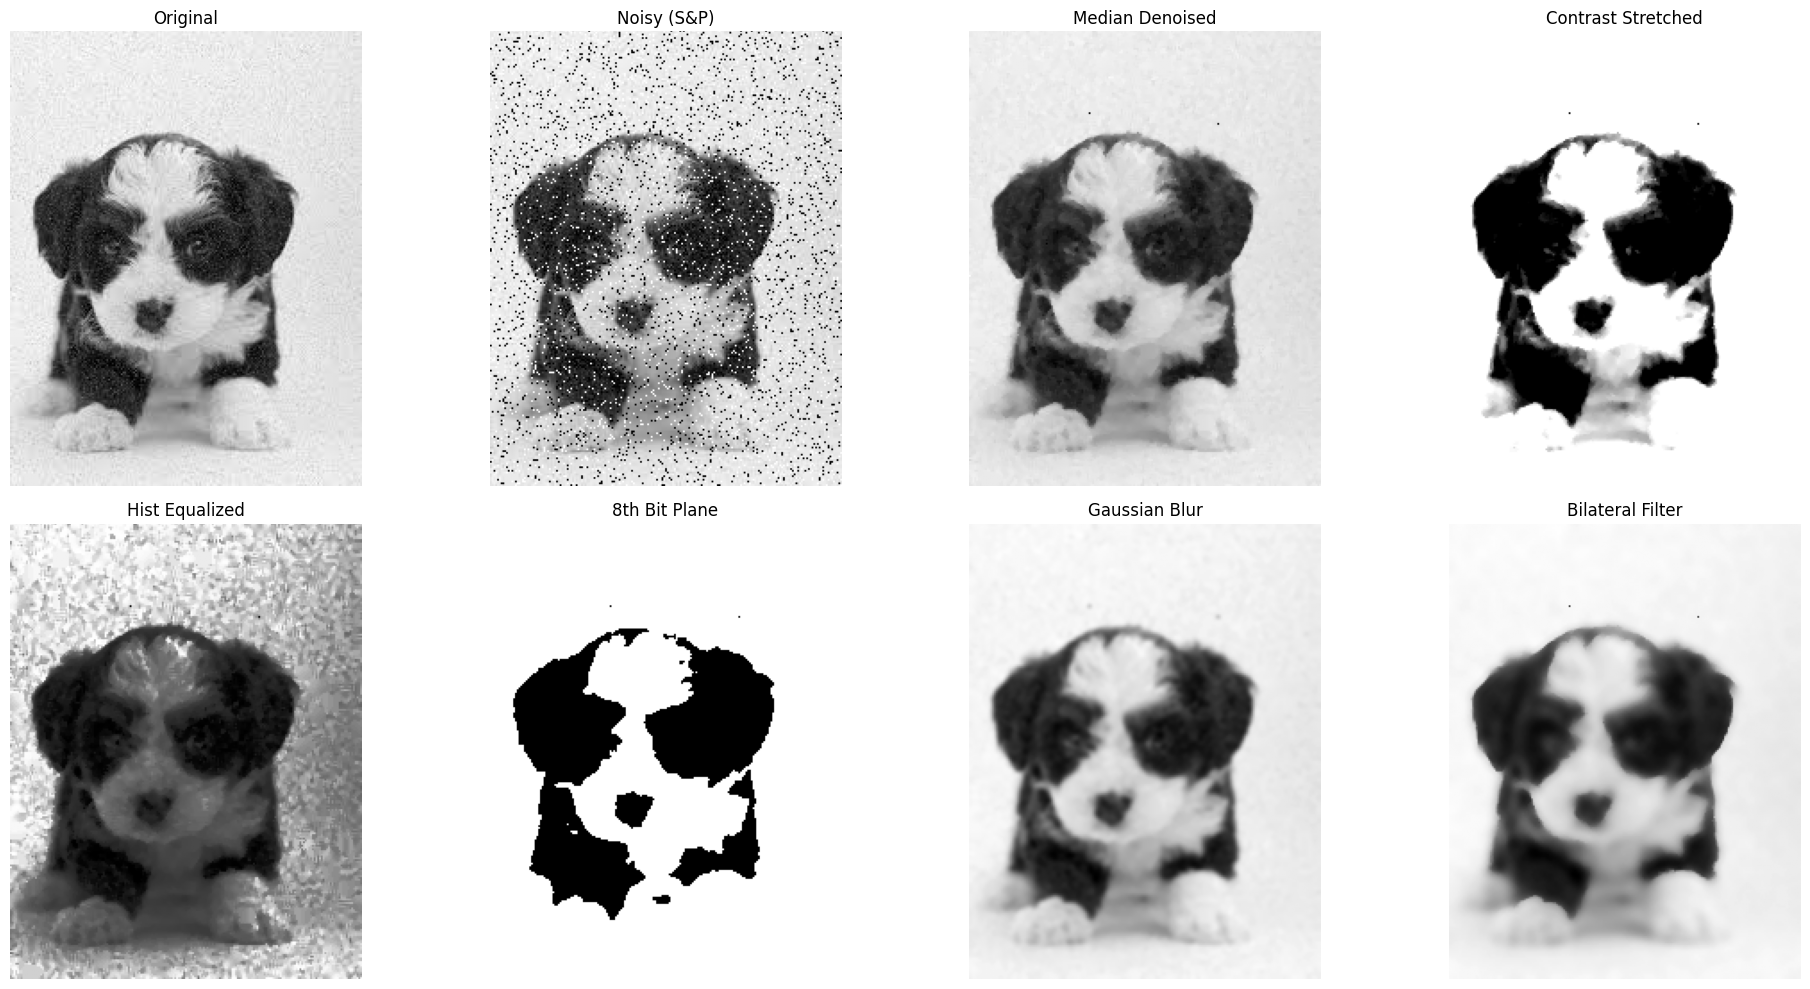

In [ ]:
# Integrated Challenge

img = cv2.imread('dog.jpg', cv2.IMREAD_GRAYSCALE)

noisy_img = img.copy()
prob = 0.05
thresh = 1 - prob
for i in range(img.shape[0]):
    for j in range(img.shape[1]):
        rdn = np.random.random()
        if rdn < prob:
            noisy_img[i][j] = 0
        elif rdn > thresh:
            noisy_img[i][j] = 255

denoised_median = cv2.medianBlur(noisy_img, 3)

r1, r2 = 60, 180
stretched = np.clip((denoised_median.astype(np.float32) - r1) * (255 / (r2 - r1)), 0, 255).astype(np.uint8)

equalized = cv2.equalizeHist(denoised_median)

bit_plane_8 = (denoised_median >> 7) & 1
bit_plane_8 = bit_plane_8 * 255

gaussian = cv2.GaussianBlur(denoised_median, (5, 5), 0)
bilateral = cv2.bilateralFilter(denoised_median, 9, 75, 75)

plt.figure(figsize=(20, 10))

titles = ['Original', 'Noisy (S&P)', 'Median Denoised', 'Contrast Stretched', 'Hist Equalized', '8th Bit Plane', 'Gaussian Blur', 'Bilateral Filter']
images = [img, noisy_img, denoised_median, stretched, equalized, bit_plane_8, gaussian, bilateral]

for i in range(8):
    plt.subplot(2, 4, i+1)
    plt.imshow(images[i], cmap='gray')
    plt.title(titles[i])
    plt.axis('off')

plt.tight_layout()
plt.show()

### Observations

1.  **Effectiveness of Median Filter**: The median filter works exceptionally well in eliminating impulsive salt-and-pepper noise as it uses the local median to replace noisy pixels while linear filters like Gaussian blur will just blur out the noise with other adjacent pixels.
2.  **Comparison between Contrast and Histogram Equalization**: Contrast stretching involves the amplification of only a portion of the intensity levels from r1 to r2 to the whole [0, 255] range while histogram equalization tries to make the whole intensity level flat with higher contrast.
3.  **Importance of 8th Bit Plane**: 8th bit plane which is also the most significant bit plane (MSB) holds most of the structural information in the form of shapes and contours, and even after denoising; it shows all the structural information clearly.
4.  **Comparison between Gaussian and Bilateral Filter**: Even though both Gaussian and bilateral filters help in smoothing out the image, the latter helps in preserving the sharp edges as it takes into account both spatial and intensity differences.
5.  **Chain Effects**: Applying any kind of enhancement on top of a denoising technique can sometimes highlight some of the artifacts left by the filter as a result of the denoising process.

## 1.5 Application Problems (Higher Difficulty)

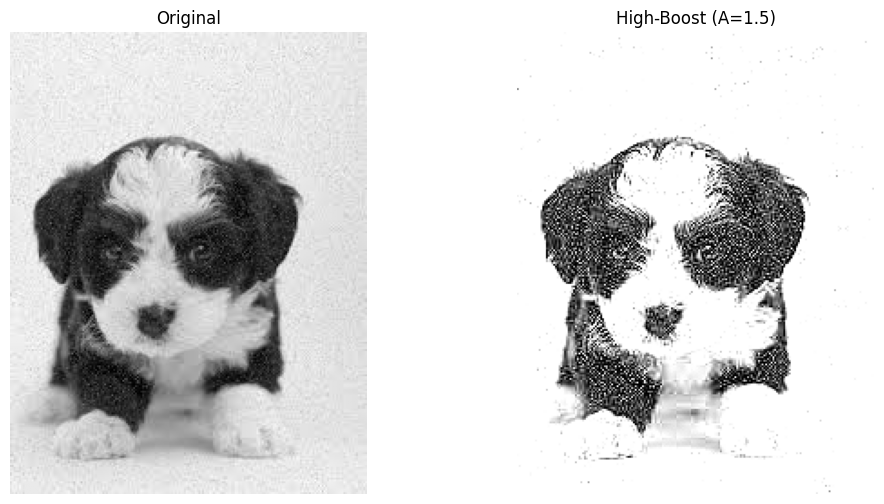

In [7]:

img = cv2.imread('dog.jpg', cv2.IMREAD_GRAYSCALE)

# Step 1: Sharpen the image (using Laplacian)
# f_sharpened = f_orig + mask
laplacian = cv2.Laplacian(img, cv2.CV_64F)
f_sharpened = img - laplacian

# Step 2: High-Boost Filtering formula: f_hb = (A - 1) * f_orig + f_sharpened
A = 1.5
high_boost = (A - 1) * img.astype(np.float64) + f_sharpened
high_boost = np.clip(high_boost, 0, 255).astype(np.uint8)

plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
plt.imshow(img, cmap='gray')
plt.title('Original')
plt.axis('off')

plt.subplot(1, 2, 2)
plt.imshow(high_boost, cmap='gray')
plt.title(f'High-Boost (A={A})')
plt.axis('off')
plt.show()

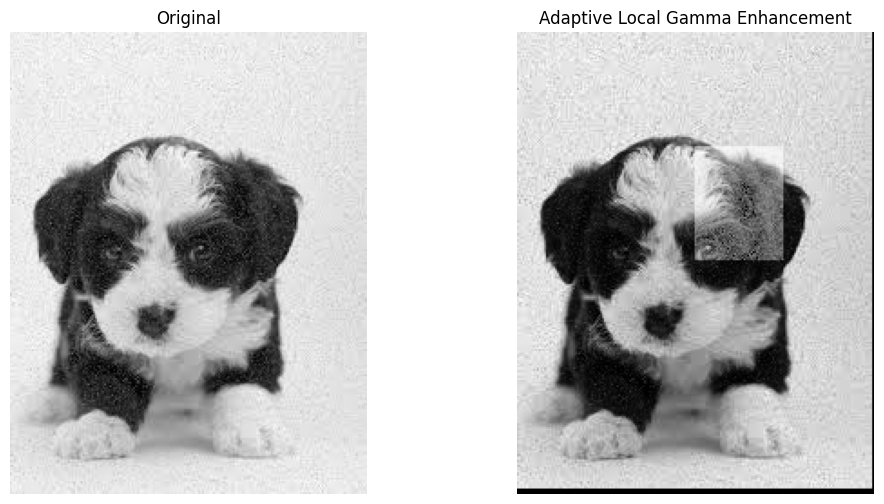

In [5]:
# Adaptive Local Enhancement (Local Gamma Correction)
def apply_local_gamma(img, grid_size=(4, 4)):
    h, w = img.shape
    gh, gw = h // grid_size[0], w // grid_size[1]
    res = np.zeros_like(img, dtype=np.float32)
    img_norm = img.astype(np.float32) / 255.0

    for i in range(grid_size[0]):
        for j in range(grid_size[1]):
            # Define sub-region
            y1, y2 = i * gh, (i + 1) * gh
            x1, x2 = j * gw, (j + 1) * gw
            region = img_norm[y1:y2, x1:x2]

            # Calculate local brightness to decide gamma
            avg_brightness = np.mean(region)
            # If dark (avg < 0.5), use gamma < 1 to brighten; else gamma > 1 to darken/increase contrast
            gamma = 0.5 if avg_brightness < 0.5 else 1.5

            res[y1:y2, x1:x2] = np.power(region, gamma)

    return (res * 255).astype(np.uint8)

adaptive_img = apply_local_gamma(img)

plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
plt.imshow(img, cmap='gray')
plt.title('Original')
plt.axis('off')

plt.subplot(1, 2, 2)
plt.imshow(adaptive_img, cmap='gray')
plt.title('Adaptive Local Gamma Enhancement')
plt.axis('off')
plt.show()